In [ ]:
!python -m spacy download en_core_web_sm

In [ ]:
import sys
sys.executable


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import seaborn as sns
import spacy, inflect
from pprint import pprint


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from utils.lib import get_phrases, normalize_text, singularize_nouns
# Load corpus
# with open("/content/drive/MyDrive/cleaned_corpus_final2.txt", "r") as file:
# with open("./datasets/OpenBookQA-V1-Sep2018/Data/Main/openbook.txt", "r") as file:
with open("./datasets/test/corpus.txt", "r") as file:
    corpus = file.readlines()

phrases = get_phrases(corpus)
pprint(phrases)

[('textual datum', 11),
 ('task', 10),
 ('word', 9),
 ('algorithm', 9),
 ('LLM', 9),
 ('text', 8),
 ('their ability', 8),
 ('sentiment analysi', 7),
 ('entity recognition', 5),
 ('language', 5),
 ('context', 4),
 ('Text Processing algorithm', 4),
 ('humanlike text', 3),
 ('the accuracy', 3),
 ('application', 3),
 ('information extraction', 3),
 ('phrase', 3),
 ('user experience', 3),
 ('chatbot', 3),
 ('user', 3),
 ('mathematical operation', 2),
 ('semantic relationship', 2),
 ('analysi', 2),
 ('semantic meaning', 2),
 ('word analogy word similarity', 2),
 ('document', 2),
 ('entity recognition assist', 2),
 ('language generation', 2),
 ('text classification', 2),
 ('relationship', 2),
 ('word phrase', 2),
 ('concept', 2),
 ('contextually relevant response', 2),
 ('customer feedback', 2),
 ('large volume', 2),
 ('efficiency', 2),
 ('humanlike response', 2),
 ('user experience LLM', 2),
 ('poetry', 2),
 ('their creativity', 2),
 ('social media', 2),
 ('NLP task', 2),
 ('NLP application'

In [10]:
# Get phrases from the corpus
phrases = [phrase[0] for phrase in get_phrases(corpus)]

# Initialize the document vectors
num_contexts = len(corpus)
num_phrases = len(phrases)
document_vectors = np.zeros((num_contexts, num_phrases), dtype=int)

# Fill in the document vectors
for i, context in enumerate(corpus):
    print(f"||--->>>> Context #{i:<4}\n")
    print(f"Raw Context : {context}")
    normalized_context = normalize_text(context)
    singularized_context = singularize_nouns(normalized_context)
    print(f"Normalized Context : {singularized_context}")
    
    for j, phrase in enumerate(phrases):
        if phrase in singularized_context:
            print(f"\t\tPhrase: {phrase}")
            document_vectors[i, j] = 1
    print("----------------")


||--->>>> Context #0   

Raw Context : LLMs (Large Language Models) are advanced natural language processing models that can handle massive amounts of text data.

Normalized Context : LLM Large Language Model are advanced natural language processing model that can handle massive amount of text datum
		Phrase: LLM
		Phrase: text
		Phrase: language
		Phrase: LLM Large Language Model
		Phrase: massive amount
		Phrase: natural language
		Phrase: datum
		Phrase: processing
		Phrase: text datum
----------------
||--->>>> Context #1   

Raw Context : NLP (Natural Language Processing) is a field of AI that focuses on the interaction between computers and humans through natural language.

Normalized Context : NLP Natural Language Processing i a field of AI that focus on the interaction between computer and human through natural language
		Phrase: language
		Phrase: a field
		Phrase: AI
		Phrase: the interaction
		Phrase: computer
		Phrase: natural language
		Phrase: NLP
----------------
||--->>

In [ ]:
# Print the document vectors
pprint(document_vectors)

In [8]:


# Tokenize the corpus
tokenized_corpus = [context.split() for context in corpus]

# Create the vocabulary set
vocabulary = set(word for context in tokenized_corpus for word in context)

# Initialize the document vectors
num_contexts = len(corpus)
num_vocab = len(vocabulary)
document_vectors = np.zeros((num_contexts, num_vocab), dtype=int)

# Fill in the document vectors
for i, context in enumerate(tokenized_corpus):
    for j, word in enumerate(vocabulary):
        if word in context:
            document_vectors[i, j] = 1

# # TF-IDF vectorization
# tfidf_vectorizer = TfidfVectorizer(max_features=4130)
# tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# # Dimensionality reduction
# n_components = 4130
# svd = TruncatedSVD(n_components=n_components)
# document_vectors = svd.fit_transform(tfidf_matrix)
pprint(document_vectors)


[[0 0 0 ... 0 0 1]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]]


In [ ]:

# Clustering with UMAP
umap_model = umap.UMAP(n_components=2, random_state=123)
document_vectors_umap = umap_model.fit_transform(document_vectors)

# Create a 16x16 grid
grid_size = 32
grid = np.zeros((grid_size, grid_size), dtype=int)

# Map document_ids to grid coordinates
for i, (x, y) in enumerate(document_vectors_umap):
    document_id = i + 1
    row = int((y - document_vectors_umap[:, 1].min()) / (document_vectors_umap[:, 1].max() - document_vectors_umap[:, 1].min()) * (grid_size - 1))
    col = int((x - document_vectors_umap[:, 0].min()) / (document_vectors_umap[:, 0].max() - document_vectors_umap[:, 0].min()) * (grid_size - 1))
    grid[row, col] += 1

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
ax = sns.heatmap(grid, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Number of Documents"})
plt.xlabel('Column')
plt.ylabel('Row')
plt.title('Document Distribution Heatmap')
ax.invert_yaxis()
plt.show()

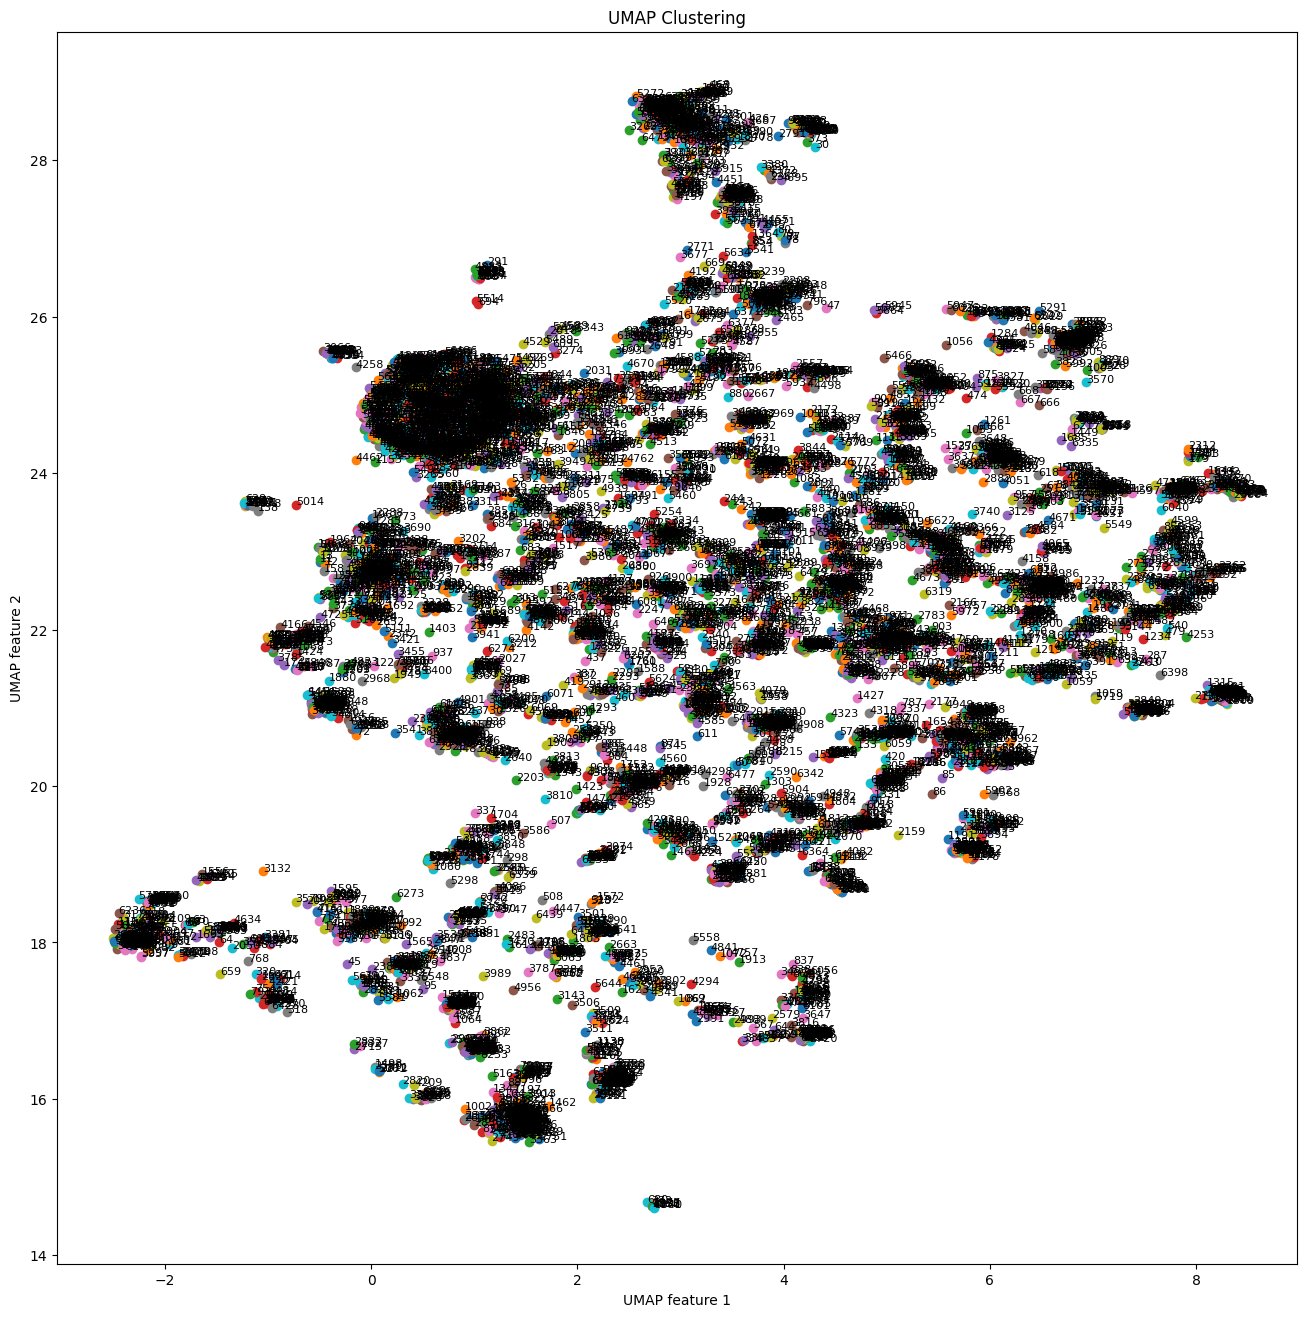

In [ ]:
# Plot UMAP clusters
plt.figure(figsize=(16, 16))
for i, (x, y) in enumerate(document_vectors_umap):
    document_id = i + 1
    plt.scatter(x, y)
    plt.annotate(str(document_id), (x, y), fontsize=8)  # Adjust the fontsize parameter
plt.xlabel('UMAP feature 1')
plt.ylabel('UMAP feature 2')
plt.title('UMAP Clustering')
plt.show()

In [ ]:
import numpy as np

def calculate_euclidean_distance(vector1, vector2):
    return np.linalg.norm(vector1 - vector2)

# Get the number of document vectors
max_id = len(document_vectors_umap)
# Calculate all possible pairwise distances
distances = []
for i in range(max_id):
    for j in range(i + 1, max_id):  # Avoid redundant calculations
        vector1 = document_vectors_umap[i]
        vector2 = document_vectors_umap[j]
        dist = calculate_euclidean_distance(vector1, vector2)
        if(dist < 0.005):
          print(i+1, j+1, dist)


17 4255 0.003127834
18 27 0.0024041587
22 3096 0.0024363992
32 1482 0.0032570662
44 2989 0.00062961073
46 558 0.004633481
48 1792 0.0018605257
77 81 0.003097927
106 1596 0.003975776
106 5652 0.0035182
114 1418 0.0027770128
127 4860 0.0026841597
129 130 0.0043908623
130 1891 0.0044224467
132 2133 0.0013260711
135 6472 0.004899514
149 156 0.0033855976
177 501 0.0021133996
177 6358 0.0028409106
188 2635 0.004822441
219 2645 0.002280316
232 3482 0.0046475222
232 3728 0.0033981407
257 3634 0.0032439067
268 4606 0.004762603
268 6100 0.0030563127
295 980 0.0029835422
299 994 0.0012362289
299 1789 0.0037754083
301 1278 0.0021981779
304 5365 0.0042018453
308 2630 0.0028175719
308 3255 0.0036993322
308 5618 0.0037456905
321 329 0.0020139585
340 2624 0.0035075434
345 2565 0.0017707347
356 5093 0.0040685735
357 574 0.0043750736
368 544 0.002130392
368 2548 0.0042345678
370 867 0.0027686397
375 1256 0.0030931055
410 5083 0.0047321846
446 6268 0.0018777297
501 6358 0.002997005
506 3470 0.0033639981
